In [1]:
import pandas as pd
df = pd.read_excel("D598 Data Set.xlsx")
df2 = df.drop_duplicates()
df3 = df2.groupby("Business State").agg(['mean', 'median', 'min', 'max'])
df3.columns = ['_'.join(col) for col in df3.columns] 
df3.reset_index(inplace=True)
df4 = df2[df2['Debt to Equity'] < 0]
df2['Debt-to-Income Ratio'] = df2.apply(
lambda row: 0 if row['Total Revenue'] == 0 else row['Total Long-term Debt'] / row['Total Revenue'],
axis=1
)
df5 = df2[['Debt-to-Income Ratio']]
df6 = pd.concat([df2, df5], axis=1)

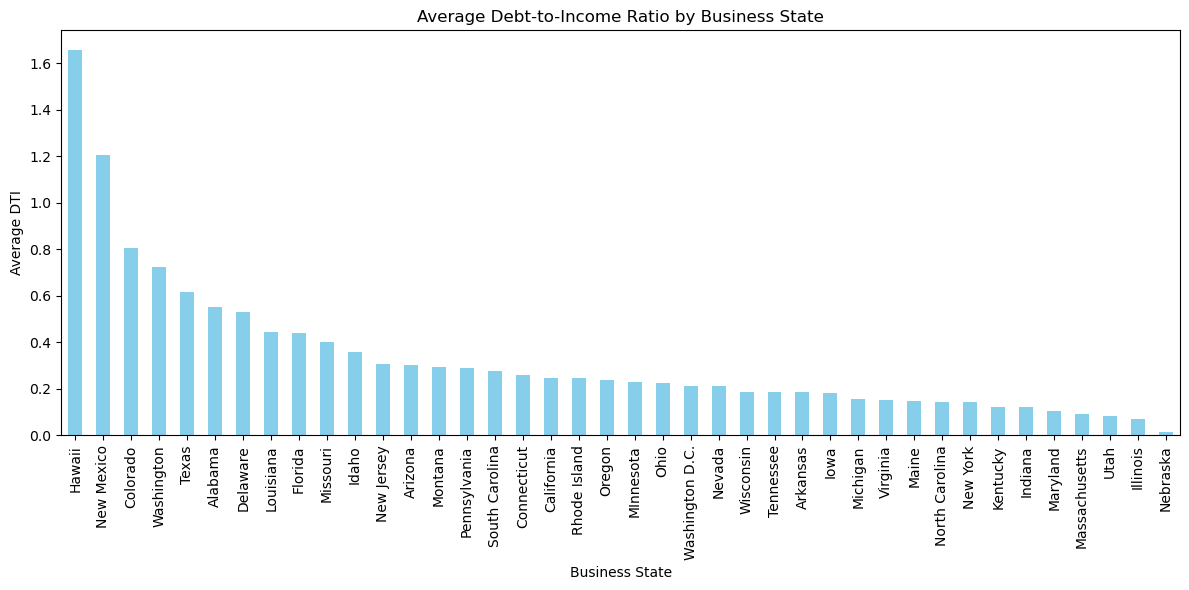

In [18]:
import matplotlib.pyplot as plt

state_avg_dti = df2.groupby('Business State')['Debt-to-Income Ratio'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
state_avg_dti.plot(kind='bar', color='skyblue')
plt.title('Average Debt-to-Income Ratio by Business State')
plt.xlabel('Business State')
plt.ylabel('Average DTI')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

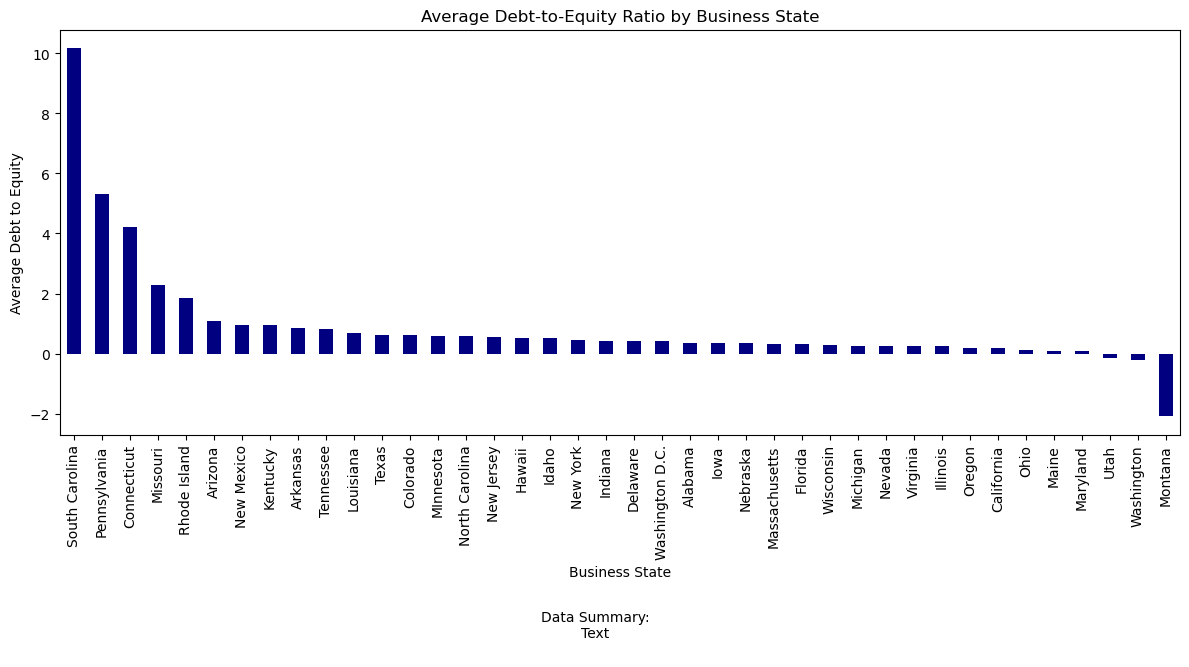

In [23]:
dept_to_equity_by_state = df.groupby('Business State')['Debt to Equity'].mean().sort_values(ascending=False)
plt.figure(figsize=(12,6))
dept_to_equity_by_state.plot(kind='bar', color='navy')
plt.title('Average Debt-to-Equity Ratio by Business State')
plt.xlabel('Business State')
plt.ylabel('Average Debt to Equity')
plt.xticks(rotation=90)
summary_dte = f"""
Data Summary:
Text
"""
plt.figtext(0.5, -0.0, summary_dte, fontsize=10, ha='center', va='top') 
plt.tight_layout()
plt.show()